# What Is Intrinsic Dimension?

**Ambient space** is the surrounding, high-dimensional coordinate space $\mathbb{R}^D$ in which a dataset is natively represented, regardless of how much of that space the data actually fills. For example, the ambient dimension of a feature vector is simply the length of the feature vector.

In contrast, the **intrinsic dimension (ID)** is the minimal number of parameters, $d$, needed to describe the true underlying data distribution, independent of the ambient space in which it is embedded. For example, a dataset may live in an ambient space of $\mathbb{R}^{768}$, but if all points lie entirely on a 2-dimensional curved surface, its ID is 2. (Ansuini et al., 2019 - *[4]*), *[5]*

Formally, the manifold hypothesis states that high-dimensional data $\{x_i\}_{i=1}^N \subset \mathbb{R}^D$ does not fill the ambient space uniformly. It instead lies on or near a low-dimensional submanifold $\mathcal{M}$ with $\text{dim}(\mathcal{M}) = d \ll D$. *[4]*

## Ok why use ID?

Our main goal is an even stronger test of the Platonic Representation Hypothes. UniverseTBD et al., 2025 showed that astronomy foundation models arrange the same galaxies into similar neighborhoods as measured by the mutual k-nearest-neighbor (MKNN) metric. However, we don't know whether these models converge on a shared, physically interpretable coordinate system. Do astronomy foundation models encode a physical quantity like stellar mass, redshift, luminosity, SFR, metallicity as an identifiable, recoverable **direction** in their representations, and do the geometry of those directions reproduce known astrophysical scaling relations (mass–luminosity, the star-forming main sequence, mass–metallicity)?

That entire goal rests on the assumption that the physics is stored *linearly* within these models. A quantity is "stored linearly" if its value increases steadily as you move along one straight axis through the representation, so that reading the quantity off or identifying and removing that axis can be done with simple linear operations (linear probe). If instead the quantity is smeared across a curved surface, no single straight axis describes it and those linear operations are the wrong tool. 

Intrinsic dimension is what lets us **test that assumption rather than assume it**. By the manifold hypothesis, our embeddings sit in an ambient space $\mathbb{R}^D$ (the model's hidden width) but concentrate near a submanifold $\mathcal{M}$ of much smaller dimension $d \ll D$. Estimating $d$, and comparing it against the *flat* (linear) dimension of the same data, is what tells us whether the direction based picture is trustworthy. Quantity by quantity, it also reveals whether "direction" is even the right description. We want to use ID in five different ways.

- **Per block: can a linear subspace contain the representation at all?**
For each transformer block, we compare two numbers. The first is the ID, and the second is the linear dimension (the number of principal components needed to account for most of the spread in the data). When these two agree, the block is approximately flat and a linear subspace can hold it so describing the data with straight directions is valid. When the ID is much smaller than the linear dimension, the representation is curved and folded so that it needs many linear axes to enclose it even though it truly varies along few. Any linear direction we extract is only a projection of something nonlinear. This is the geometric form of Ansuini et al.'s (2019) question: can a flat linear subspace contain a curved data manifold? The answer, block by block, is the caveat we must attach to every direction we later report from that block.
<!-- The gap is judged against the gap produced by the anisotropic Gaussian null, not against zero, because covariance shape alone induces some separation. -->
<!-- principal components here just means straight mutually perpendicular axes  -->

- **Across depth: where does the clean structure live?**
Plotting ID block by block typically traces the rise-then-fall pattern (expand in early, compress later) Ansuini et al. (2019) reported for deep networks. The compressed region near the trough is where the representation is most concentrated , and it is where semantically clean, recoverable directions tend to live. This makes ID a principled way to select which blocks carry our main results, rather than treating every layer as equally interpretable.

- **Per quantity: is a quantity a direction or a manifold?**
This is the most useful to our goal. For each physical quantity, say stellar mass, we estimate the ID of that quantity's recovered **level sets**. Level sets are the sets of embedding points that all share the same physical quantity (ex. same stella mass), one such set per value, like contour lines on a map. If this quantity is stored along a single linear axis, these contours are flat, parallel sheets stacked perpendicular to that axis, and the collection has an ID of 1. If the quantity is stored on a curved manifold, the contours bend and the collection has ID above 1. We also check how well the quantity can be predicted from the representation by a linear probe versus a nonlinear probe. Agreement between ID ~ 1 and a linear probe that has a small $R^2$ gap with the nonlinear probe means the quantity is actually a direction, and the simple linear operations apply. ID > 1 or a large probe gap means the quantity is a manifold and identifying or removing it has to be done nonlinearly or subspace based. The verdict thus *chooses the method for each quantity* instead of the method being fixed in advance. 

- **Per population: is a single ID number meaningful for this data?**
Real embeddings mix heterogeneous populations (galaxies, stars, AGN, QSOs, lensed sources) in one space. A global estimator returns one number, which can be misleading if those populations occupy manifolds of different dimension. So instead of one global number, we look at the distribution of local dimension estimates, computed point by point across the data AKA *pointwise distribution*. A bimodal or multimodal distribution spread flags that a single "mass direction" may be averaging across populations that should be conditioned on separately. This check is specific to our astronomy setting. 

- **Cross-cutting: is any reported ID trustworthy?**
To ensure our IDs reflect actual geometric structure, we apply two different tests. Real neural activations spread widely in a few directions while remaining narrow in others. Because estimators can mistake this anisotropic shape for low-dimensional structure, we compare our IDs against IDs of synthetic, structureless noise with the exact same covariance profile. A valid ID estimate must fall past the relevant quantile of this "anisotropic null" distribution to prove it is not a mere artifact of the data's spread. Nearest-neighbor estimators like TwoNN systematically underestimate the dimension of high-ID manifolds. To account for this, the estimate is calibrated against a measured bias curve derived from high-ID benchmark manifolds. Nearest-neighbor estimators also inflate toward the ambient dimension when noise dominates the smallest neighbor distances, making a flat block read as curved or a true ID-1 level set read above 1. We measure this against clean manifolds corrupted with isotropic noise at known SNR."

ID characterizes *what kind of object* each quantity is (a direction or manifold) and *whether the linear frame is trustworthy* where we read it. It does not tell us which direction a quantity occupies, its sign, or its slope against another quantity. Those come later from probes. It does not tell us whether two quantities are entangled. ID is the precondition that makes those downstream, labeled, quantitative results correctly typed and defensible since every one of them is conditioned on the verdict ID returns.

# 1.0 Setup and Imports

In [26]:
# Imports
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Callable, Optional, Union

import numpy as np
from scipy.stats import ortho_group
import skdim.datasets as skd
import matplotlib.pyplot as plt

# =====================================================================
# Output container
# =====================================================================
@dataclass
class SyntheticDataset:
    """Container for one synthetic draw.

    Attributes
    ----------
    name : generator name.
    X : (n, D) data matrix.
    id_true : ground-truth intrinsic dimension. ``int`` for single
        manifolds, ``dict`` for mixed-population sets (Use 4), and for
        nulls it equals the ambient dimension D.
    y : (n,) planted scalar quantity (only ``planted_quantity``).
    labels : (n,) integer population labels (only heterogeneous sets).
    meta : full parameter record (seed, snr, sigma, mode, source, ...).
    """
    name: str
    X: np.ndarray
    id_true: Union[int, dict]
    y: Optional[np.ndarray] = None
    labels: Optional[np.ndarray] = None
    meta: dict = field(default_factory=dict)
    @property
    def n(self) -> int:
        return self.X.shape[0]
    @property
    def ambient_dim(self) -> int:
        return self.X.shape[1]

# =====================================================================
# RNG/Helpers
# =====================================================================
def _rng(seed: Optional[int]) -> np.random.Generator:
    return np.random.default_rng(seed)

def _haar(D: int, rng: np.random.Generator) -> np.ndarray:
    """Haar-distributed orthogonal matrix, seeded from ``rng``.

    ``ortho_group.rvs`` is given an integer seed drawn from ``rng`` so
    behavior is identical across scipy versions that do / don't accept
    ``np.random.Generator`` directly.
    """
    return ortho_group.rvs(D, random_state=int(rng.integers(2**31 - 1)))

def embed_ambient(
    X: np.ndarray,
    D: Optional[int],
    rng: np.random.Generator,
) -> np.ndarray:
    """Embed (n, d0) data into ambient R^D: zero-pad then Haar-rotate.

    The rotation is applied even when D == d0 so no generator leaks
    axis-aligned structure to estimators. ``D=None`` is a no-op
    (data stays in its native coordinates).
    """
    if D is None:
        return X
    n, d0 = X.shape
    if d0 > D:
        raise ValueError(f"ambient dim D={D} < native data dim {d0}. Ambient dim needs to be able to hold the data's native dimension.")
    Xp = np.zeros((n, D), dtype=float)
    Xp[:, :d0] = X
    return Xp @ _haar(D, rng).T

def add_isotropic_noise(
    X: np.ndarray,
    snr: Optional[float],
    rng: np.random.Generator,
) -> tuple[np.ndarray, float]:
    """Add isotropic Gaussian noise at a target SNR. Returns (X_noisy, sigma).

    SNR is defined as E||x - x_bar||^2 / E||eps||^2 with
    eps ~ N(0, sigma^2 I_D), so sigma^2 = signal_power / (snr * D).
    ``snr=None`` or ``inf`` is a no-op (sigma = 0).
    """
    if snr is None or np.isinf(snr):
        return X, 0.0
    if snr <= 0:
        raise ValueError("snr must be positive")
    D = X.shape[1]
    signal_power = float(np.mean(np.sum((X - X.mean(axis=0)) ** 2, axis=1)))
    sigma = float(np.sqrt(signal_power / (snr * D)))
    return X + rng.normal(0.0, sigma, size=X.shape), sigma

n, D, seed = 3000, 64, 42

# 1. Dummy Data Generators

Before working with astronomy foundation model embeddings, we characterize two properties of each ID estimator on synthetic data whose answer we already know: 

1) **Null distribution**: What values does the estimator return when the data has *no intrinsic low-dimensional structure*?
2) **Power**: How well does the estimator recover a known, planted structure?

Every generator below exists to calibrate a specific use of ID from the intro. An estimator or metric is only trusted on real activations once its null and power are known here first.

## 1.1 Null Distributions (No Planted Structure)
*Calibrates Use 1 and Use 5*

These generators produce data with no low-dimensional manifold signal. Their ground-truth ID equals the ambient dimension $D$. They bracket the range of covariance shapes ID estimators might encounter on real activations.

| Generator | Structure | Ground-truth ID | Purpose |
| --- | --- | --- | --- |
| `iso_gaussian` | $X \sim \mathcal{N}(0, I_d)$ — pure isotropic noise | $D$ | Simplest null: every direction equivalent, no manifold |
| `aniso_gaussian` | $X \sim \mathcal{N}(0, \Sigma)$, $\Sigma = \text{diag}(\lambda_k)$, $\lambda_k \propto k^{-\alpha}$, $\alpha=1$ | $D$ | Realistic null: shaped covariance matching observed neural spectra *[3]* |
| `oblong_normal` | Anisotropic Gaussian with **bimodal** variance: half the dims $\sigma=1$, half $\sigma=0.25$ | $D$ | Structured null modeling "few dominant PCs"; tests covariance-shape sensitivity |

**Why?**

* **Isotropic Gaussian** is the simplest possible null. Every direction is equivalent, so there is no manifold. If an ID estimator returns $\approx D$ here, the estimator is unbiased on structureless data. If it returns something much lower, it has a systematic bias even on structureless data.
* **Anisotropic Gaussian with power-law spectrum** ($\alpha = 1$) mimics the empirically observed eigenspectrum of neural population responses and deep-network representations. Stringer et al. (2019) showed that neural covariance eigenvalues follow $\lambda_k \propto k^{-(1+2/d)}$, and at $\alpha \approx 1$ the code is "maximally high-dimensional while remaining a smooth manifold." This is the realistic null where real activations are never isotropic, so the anisotropic null is the one whose quantiles matter for interpretation. *[3]*
* **Oblong Normal** has a sharp bimodal variance split (half the dimensions carry $16\times$ the variance of the other half), which models a layer where a few principal components dominate. This is a plausible structure for real activations and a complementary null to the smooth power-law decay. If an estimator returns different null values on oblong vs power-law at the same $D$, the estimator is sensitive to covariance *shape*, not just anisotropy.

In [2]:
def iso_gaussian(n: int, D: int, seed: Optional[int] = None) -> SyntheticDataset:
    rng = _rng(seed)
    X = rng.normal(size=(n, D))
    return SyntheticDataset("iso_gaussian", X, D, meta=dict(seed=seed))

def aniso_gaussian(
    n: int,
    D: int,
    alpha: float = 1.0,
    rotate: bool = True,
    seed: Optional[int] = None,
) -> SyntheticDataset:
    rng = _rng(seed)
    lam = np.arange(1, D + 1, dtype=float) ** (-alpha)
    X = rng.normal(size=(n, D)) * np.sqrt(lam)
    if rotate:
        X = X @ _haar(D, rng).T
    return SyntheticDataset(
        "aniso_gaussian", X, D,
        meta=dict(seed=seed, alpha=alpha, rotate=rotate, eigenvalues=lam,
                  source="Stringer et al. 2019 Nature 571:361"),
    )

def oblong_normal(
    n: int,
    D: int,
    sigma_hi: float = 1.0,
    sigma_lo: float = 0.25,
    rotate: bool = True,
    seed: Optional[int] = None,
) -> SyntheticDataset:
    rng = _rng(seed)
    d_hi = int(np.ceil(D / 2))
    sig = np.concatenate([np.full(d_hi, sigma_hi), np.full(D - d_hi, sigma_lo)])
    X = rng.normal(size=(n, D)) * sig
    if rotate:
        X = X @ _haar(D, rng).T
    return SyntheticDataset(
        "oblong_normal", X, D,
        meta=dict(seed=seed, sigma_hi=sigma_hi, sigma_lo=sigma_lo,
                  n_hi=d_hi, rotate=rotate),
    )

Because these nulls are high-dimensional Gaussians with no manifold structure, plotting the raw points would just show a shapeless cloud regardless of which generator produced it. The property that actually distinguishes these generators is how variance is distributed across directions. We can use the eigenvalue spectrum to reveal this:
- A flat line for isotropic variance,
- A straight diagonal for smooth power-law decay,
- A visible step for the bimodal split.

Plotting on log-log axes turns the power-law case into a readable straight line and makes the decay rate (the quantity our ID estimator calibration actually cares about) directly visible by eye.

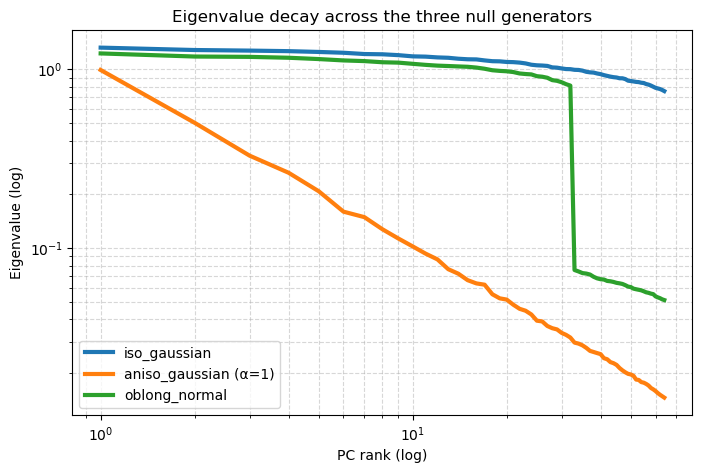

In [27]:
ds_iso    = iso_gaussian(n, D, seed=seed)
ds_aniso  = aniso_gaussian(n, D, seed=seed)
ds_oblong = oblong_normal(n, D, seed=seed)
def eigenspectrum(X):
    Xc = X - X.mean(axis=0)
    cov = (Xc.T @ Xc) / (Xc.shape[0] - 1)
    return np.clip(np.linalg.eigvalsh(cov)[::-1], 1e-12, None)

specs = {
    "iso_gaussian": eigenspectrum(ds_iso.X),
    "aniso_gaussian (α=1)": eigenspectrum(ds_aniso.X),
    "oblong_normal": eigenspectrum(ds_oblong.X),
}

fig, ax = plt.subplots(figsize=(8, 5))
k = np.arange(1, D + 1)

# plot each eigenspectrum
for name, lam in specs.items():
    ax.plot(k, lam, label=name, linewidth=3)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("PC rank (log)")
ax.set_ylabel("Eigenvalue (log)")
ax.set_title("Eigenvalue decay across the three null generators")
ax.legend()
ax.grid(True, which="both", linestyle="--", alpha=0.5)

So, we can see that the blue `iso_gaussian` line is nearly flat (slight downward drift is normal sampling noise from finite `n`), consistent with all directions carrying equal variance and no covariance shape at all. The orange `aniso_gaussian` line traces a clean, nearly straight diagonal on log-log axes across the full rank range, which is exactly the signature of a power-law eigenvalue decay $(\lambda_k \propto k^{-1})$. The green `oblong_normal` line shows the expected two-tier structure: a near-flat plateau near 1 for the first ~32 ranks, then a sharp vertical drop to a lower plateau near 0.06 for the remaining ranks, matching the bimodal sigma_hi/sigma_lo variance split by design.

## 1.2 Planted Quantity (Direction vs Manifold)
*Calibrates Use 3*

| Generator | Mode | Level-set ID | Probe gap | Role |
| --- | --- | --- | --- | --- |
| `planted_quantity` | linear: $y = w\cdot x + \varepsilon$ | $\approx 1$ | $\approx 0$ | Null for "quantity is a direction" |
| `planted_quantity` | nonlinear: $y$ along a curved manifold coordinate | $> 1$ | $> 0$ | Power for "quantity is a manifold" |

**Why?**

In **linear** mode, the quantity varies along one fixed direction. Level sets are parallel hyperplanes where the trajectory swept as `y` varies is straight (ID $\approx 1$), and a linear probe matches a nonlinear one (gap $\approx 0$). In **nonlinear** mode, `y` varies along a curved coordinate where the trajectory bends (ID $> 1$) and the nonlinear probe wins. SNR is controllable. This tells us what "a direction" versus "a manifold" *looks like* under our own metrics before we apply the verdict to real quantities.

**Choosing the curved coordinate**

The nonlinear centerline is deliberately a multi-turn Archimedean spiral rather than a simpler bending curve. A curve like $[t, {(t-1/2)}^2, sin(2\pi t)]$ still has enough linear structure that an ambient linear probe decodes it with (measured empircally $R^2 \approx 0.994$), which would make the probe gap we're trying to measure vanish. A multi-turn expanding spiral has no linear combination of coordinates that stays monotone along it, so the label is stored nonlinearly rather than just weakly linearly.

The planted label is the curve's arclength, not its raw angle. The physical quantities this is meant to stand in for (stellar mass, redshift, metallicity) are ordered, non-periodic scalars, so the synthetic label needs the same property. Arclength increases monotonically and stays single-valued along the spiral, while a raw angle wraps every 360 degrees and would make the same label value reappear at multiple points as the spiral turns.

The nuisance directions are constructed orthogonal to the spiral's plane rather than following the curve's exact Frenet normal frame. This still gives a valid tubular embedding because the nuisance dimensions add width around the manifold without corrupting its intrinsic dimension. This helps us avoid machinery that isn't necessary for this calibration.

In [10]:
def _curved_centerline(
    a: float, b: float, nturn: float, scale: float
) -> Callable[[np.ndarray], np.ndarray]:
    """Archimedean spiral: gamma(t) = scale*(a+b*t)*[cos(th), sin(th)],
    th = 2*pi*nturn*t, t in [0,1]. Same parametrization family as the
    swiss roll centerline (skdim defaults a=1, b=2-a, nturn=1.5).
    """
    def gamma(t: np.ndarray) -> np.ndarray:
        th = 2.0 * np.pi * nturn * t
        r = scale * (a + b * t)
        return np.stack([r * np.cos(th), r * np.sin(th)], axis=-1)
    return gamma

def _arclength_reparam(
    gamma: Callable[[np.ndarray], np.ndarray],
    n_grid: int = 20001,
) -> tuple[Callable[[np.ndarray], np.ndarray], float]:
    """Return (s -> t) inverse map and total curve length.

    s in [0, 1] is normalized geodesic arclength along gamma. Built by
    dense numerical cumulative arclength + linear interpolation, so
    sampling s ~ Uniform(0,1) gives points uniform in arclength (uniform
    density on the curve), and the planted label y = s is the intrinsic
    coordinate rather than the embedding-dependent parameter t.
    """
    t_grid = np.linspace(0.0, 1.0, n_grid)
    pts = gamma(t_grid)
    seg = np.linalg.norm(np.diff(pts, axis=0), axis=1)
    cum = np.concatenate([[0.0], np.cumsum(seg)])
    total = cum[-1]
    s_grid = cum / total

    def t_of_s(s: np.ndarray) -> np.ndarray:
        return np.interp(s, s_grid, t_grid)

    return t_of_s, float(total)

def planted_quantity(
    n: int,
    D: int,
    mode: str = "linear",
    m_nuisance: int = 8,
    tube_width: float = 0.25,
    snr: Optional[float] = None,
    label_noise: float = 0.0,
    spiral_a: float = 1.0,
    spiral_b: float = 1.0,
    nturn: float = 1.5,
    curve_scale: float = 1.0,
    seed: Optional[int] = None,
) -> SyntheticDataset:
    """Plants a scalar y in R^D, either on a straight axis (linear mode)
    or along the arclength of a curved spiral (nonlinear mode).
    Total manifold ID in both modes = 1 + m_nuisance (before noise).
    """
    if mode not in ("linear", "nonlinear"):
        raise ValueError("mode must be 'linear' or 'nonlinear'")
    rng = _rng(seed)

    s = rng.uniform(0.0, 1.0, size=n)
    u = rng.uniform(-1.0, 1.0, size=(n, m_nuisance)) * tube_width

    if mode == "linear":
        low = np.concatenate([(s * curve_scale)[:, None], u], axis=1)
        curve_length = curve_scale
    else:
        gamma = _curved_centerline(spiral_a, spiral_b, nturn, curve_scale)
        t_of_s, curve_length = _arclength_reparam(gamma)
        center = gamma(t_of_s(s))                     # (n, 2)
        low = np.concatenate([center, u], axis=1)     # nuisance perp spiral plane

    X = embed_ambient(low, D, rng)
    X, sigma = add_isotropic_noise(X, snr, rng)
    y = s + (rng.normal(0.0, label_noise, size=n) if label_noise > 0 else 0.0)

    return SyntheticDataset(
        "planted_quantity", X, 1 + m_nuisance, y=y,
        meta=dict(seed=seed, mode=mode, m_nuisance=m_nuisance,
                  tube_width=tube_width, snr=snr, sigma_noise=sigma,
                  label_noise=label_noise, spiral_a=spiral_a,
                  spiral_b=spiral_b, nturn=nturn,
                  curve_scale=curve_scale, curve_length=curve_length,
                  quantity_coordinate=(
                      "straight axis" if mode == "linear"
                      else "normalized geodesic arclength along curved centerline"),
                  expected_levelset_id=1 if mode == "linear" else ">1",
                  expected_probe_gap="~0" if mode == "linear" else ">0"),
    )

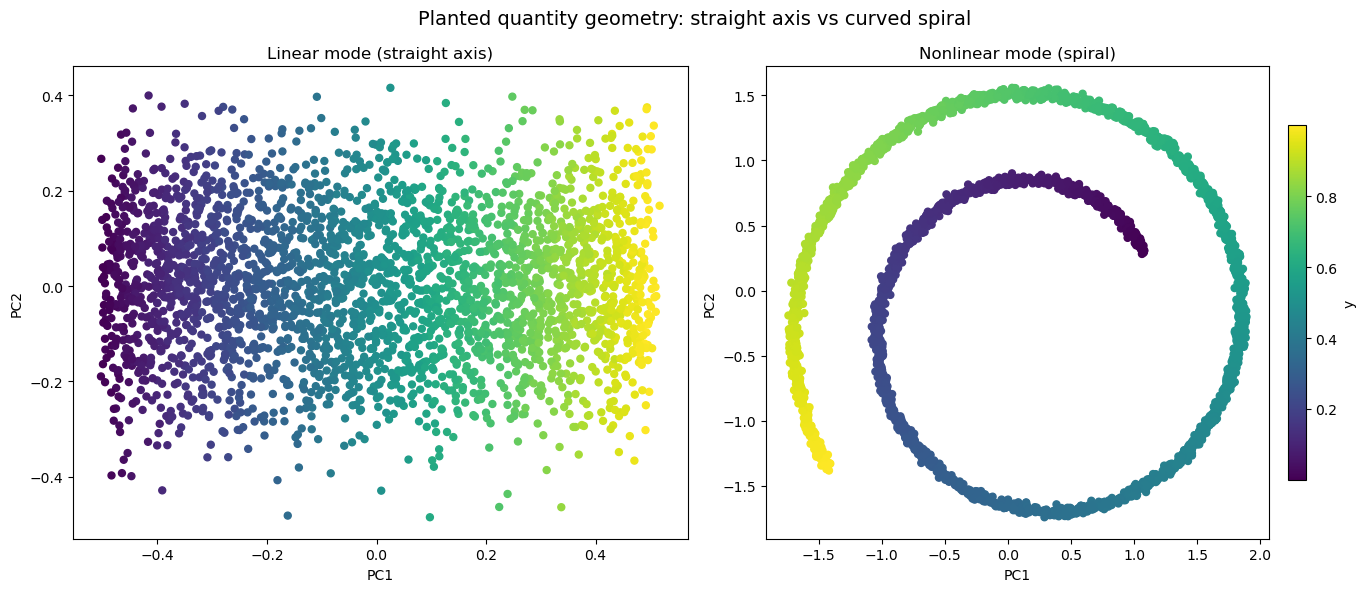

In [28]:
from sklearn.decomposition import PCA

ds_lin = planted_quantity(n, D, mode="linear", snr=100.0, seed=seed)
ds_non = planted_quantity(n, D, mode="nonlinear", snr=100.0, seed=seed)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
subplot_titles = ("Linear mode (straight axis)", "Nonlinear mode (spiral)")

for i, ds in enumerate([ds_lin, ds_non]):
    # compute 2D PCA projection
    proj = PCA(n_components=2).fit_transform(ds.X)
    # scatter on the specific axis
    sc = axes[i].scatter(
        proj[:, 0], proj[:, 1], 
        s=25, c=ds.y, cmap="viridis"
    )
    axes[i].set_title(subplot_titles[i])
    axes[i].set_xlabel("PC1")
    axes[i].set_ylabel("PC2")

cbar = fig.colorbar(sc, ax=axes[1], shrink=0.75, pad=0.03)
cbar.set_label("y")
fig.suptitle("Planted quantity geometry: straight axis vs curved spiral", fontsize=14, y=0.98)
plt.tight_layout()

In [29]:
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

def probe_gap(ds):
    Xtr, Xte, ytr, yte = train_test_split(ds.X, ds.y, test_size=0.3, random_state=0)
    sc = StandardScaler().fit(Xtr)
    Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    lin = r2_score(yte, Ridge(1.0).fit(Xtr, ytr).predict(Xte))
    mlp = r2_score(yte, MLPRegressor(hidden_layer_sizes=(256,), max_iter=500,
                                      random_state=0).fit(Xtr, ytr).predict(Xte))
    return lin, mlp, mlp - lin

for ds, name in [(ds_lin, "linear"), (ds_non, "nonlinear")]:
    lin_r2, mlp_r2, gap = probe_gap(ds)
    print(f"{name:10s}: linear R2={lin_r2:.3f}  mlp R2={mlp_r2:.3f}  gap={gap:.3f}")

linear    : linear R2=1.000  mlp R2=0.939  gap=-0.061
nonlinear : linear R2=0.075  mlp R2=0.946  gap=0.870


The linear-mode panel shows a smooth, monotone color gradient along a single axis. The nuisance dimensions (`m_nuisance`) add scatter but don't break the trend, consistent with Ridge achieving $R^2 ≈ 1.0$. The nonlinear-mode panel shows the planted label winding along a clean expanding spiral, with no straight line tracking the color order. This is why a linear probe fails ($R^2 \approx 0.06$) while the MLP succeeds ($R^2 \approx 0.95$), confirming the quantity is genuinely stored as a manifold, not a direction.

## 1.3 Clean Manifolds (Known Planted Structure, No Noise)
*Low-ID rows calibrate Use 3 (power at the ID 1-vs-2-vs-3 boundary) and high-ID rows calibrate Use 1 and Use 5 (the bias curve).*

These generators embed a manifold of known ID into $\mathbb{R}^D$ with no additive noise testing **power**.

| Generator | Ground-truth ID | Ambient dim | Topology / structure | Source |
| --- | --- | --- | --- | --- |
| `planted_manifold` | $k$ (sweepable) | configurable $D$ | $k$-ball with nonlinear quadratic lift in a random subspace | Self-contained; matches `skdim.datasets.hyperBall` construction |
| `swiss_roll` | 2 | 3 or $D$ | Flat sheet rolled into a spiral | Facco et al. 2017; `skdim.datasets.swissRoll3Sph` |
| `hyper_twin_peaks` | $k$ (sweepable) | $k + 1$ or $D$ | Unit hypercube with a peaked height map: $z = h\prod_{i=1}^d \sin(2\pi x_i)$ | `skdim.datasets.hyperTwinPeaks` |
| `M8_Nonlinear` | 12 | 72 | Nonlinear (highly curved) manifold | Campadelli et al. 2015; `skdim.datasets.BenchmarkManifolds` |
| `M_N1` | 18 | 72 | Nonlinearly embedded manifold of high ID | Campadelli et al. 2015; `skdim.datasets.BenchmarkManifolds` |
| `M_N2` | 24 | 96 | Nonlinearly embedded manifold of high ID | Campadelli et al. 2015; `skdim.datasets.BenchmarkManifolds` |

**Why?**

* **Planted manifold** gives sweepable ground truth. By sweeping `intrinsic_dim`, we directly measure power and how tight the distribution is (precision). The self-contained ball starts from the same exact uniform $k$-ball construction used in `skdim.datasets` and then applies a nonlinear lift and random embedding to better mimic learned representations.
* **Swiss roll** is the canonical benchmark that most ID estimation papers report. Facco et al. (2017) themselves reported TwoNN $\approx 2.01$ on it, so it provides an external anchor verifying our implementation matches the literature. Its global curvature tests whether TwoNN's local-neighborhood assumption survives global curvature.
* **Hyper Twin Peaks** tests a different 2D topology from the Swiss roll. Instead of a rolled sheet, it is a flat unit hypercube with peaks and troughs induced by $z = h\prod_i \sin(2\pi x_i)$. This produces a checkerboard pattern of alternating peaks and valleys with sign-changing curvature across quadrants. This is geometrically distinct from the Swiss roll's constant-curvature spiral, so it tests whether the estimator's local-neighborhood assumption holds under oscillating curvature rather than monotonic curling. It also generalizes to arbitrary ID $k$, so it can be swept alongside `planted_manifold` for a second independent power curve. If an ID estimator recovers $\approx 2$ on both Swiss Roll and Hyper Twin Peaks at $d=2$, we have evidence it generalizes across curved geometries, not just one shape. Without it, all our low-ID evidence comes from roll-like or ball-like manifolds.
* **M8_Nonlinear (ID = 12) / M_N1 (ID = 18) / M_N2 (ID = 24)** tests accuracy at an ID much closer to the regime of real foundation-model layers. Non-uniform sampling density also stresses the ID estimator's constant density (Poisson) assumption which is a key failure mode on real data where sampling is never uniform. If TwoNN's bias grows with planted ID, these benchmarks quantify how severe that bias becomes at ID levels relevant to real representations.

In [25]:
def planted_manifold(
    n: int,
    intrinsic_dim: int,
    D: int,
    n_lift: Optional[int] = None,
    lift_scale: float = 0.5,
    seed: Optional[int] = None,
) -> SyntheticDataset:
    rng = _rng(seed)
    k = intrinsic_dim
    if n_lift is None:
        n_lift = max(2, k // 2)

    u = skd.hyperBall(
        n, d=k, radius=1.0,
        random_state=int(rng.integers(2**31 - 1)),
    )

    A = rng.normal(size=(n_lift, k, k))
    A = (A + np.transpose(A, (0, 2, 1))) / 2.0            # symmetric
    z = lift_scale * np.einsum("ni,mij,nj->nm", u, A, u)  # (n, n_lift)

    low = np.concatenate([u, z], axis=1)
    X = embed_ambient(low, D, rng)
    return SyntheticDataset(
        "planted_manifold", X, k,
        meta=dict(seed=seed, n_lift=n_lift, lift_scale=lift_scale,
                  source="skdim.datasets.hyperBall + quadratic lift"),
    )

def swiss_roll(
    n: int,
    D: Optional[int] = None,
    seed: Optional[int] = None,
) -> SyntheticDataset:
    """
    Called with n_sphere=0; skdim still returns 4 columns with the 4th
    identically zero, so we slice to the first 3
    """
    rng = _rng(seed)
    X3 = skd.swissRoll3Sph(
        n, 0, random_state=int(rng.integers(2**31 - 1))
    )[:, :3]
    X = embed_ambient(X3, D, rng)
    return SyntheticDataset(
        "swiss_roll", X, 2,
        meta=dict(seed=seed, ambient=D or 3,
                  anchor="Facco et al. 2017: TwoNN ~ 2.01",
                  source="skdim.datasets.swissRoll3Sph (4th zero col sliced)"),
    )

def hyper_twin_peaks(
    n: int,
    intrinsic_dim: int = 2,
    D: Optional[int] = None,
    height: float = 1.0,
    seed: Optional[int] = None,
) -> SyntheticDataset:
    rng = _rng(seed)
    Xk = skd.hyperTwinPeaks(
        n, d=intrinsic_dim, height=height,
        random_state=int(rng.integers(2**31 - 1)),
    )
    X = embed_ambient(Xk, D, rng)
    return SyntheticDataset(
        "hyper_twin_peaks", X, intrinsic_dim,
        meta=dict(seed=seed, height=height, ambient=D or intrinsic_dim + 1,
                  source="skdim.datasets.hyperTwinPeaks"),
    )

# Campadelli high-ID benchmarks (M8 / Mn1 / Mn2)
# Public alias -> skdim key. IDs/dims are NOT hardcoded here; they are
# read from BenchmarkManifolds.truth at call time
_BENCHMARK_ALIASES = {
    "M8_Nonlinear": "M8_Nonlinear",
    "M_N1": "Mn1_Nonlinear",
    "M_N2": "Mn2_Nonlinear",
}
def benchmark_manifold(
    name: str,
    n: int,
    seed: Optional[int] = None,
) -> SyntheticDataset:
    """
    ``name`` in {'M8_Nonlinear', 'M_N1', 'M_N2'} (aliases map to skdim
    keys 'Mn1_Nonlinear' / 'Mn2_Nonlinear'). dim and d are ALWAYS passed
    explicitly, read from ``bm.truth`` -- omitting them is broken in
    skdim 0.3.4 for these manifolds.
    """
    if name not in _BENCHMARK_ALIASES:
        raise ValueError(f"name must be one of {list(_BENCHMARK_ALIASES)}")
    key = _BENCHMARK_ALIASES[name]

    bm = skd.BenchmarkManifolds(random_state=seed)
    row = bm.truth.loc[key]
    d = int(row["Intrinsic Dimension"])
    dim = int(row["Number of variables"])

    X = bm.generate(name=key, n=n, dim=dim, d=d)
    return SyntheticDataset(
        name, np.asarray(X, dtype=float), d,
        meta=dict(seed=seed, skdim_key=key, ambient=dim,
                  description=str(row["Description"]),
                  source="Campadelli et al. 2015 via skdim.BenchmarkManifolds"),
    )

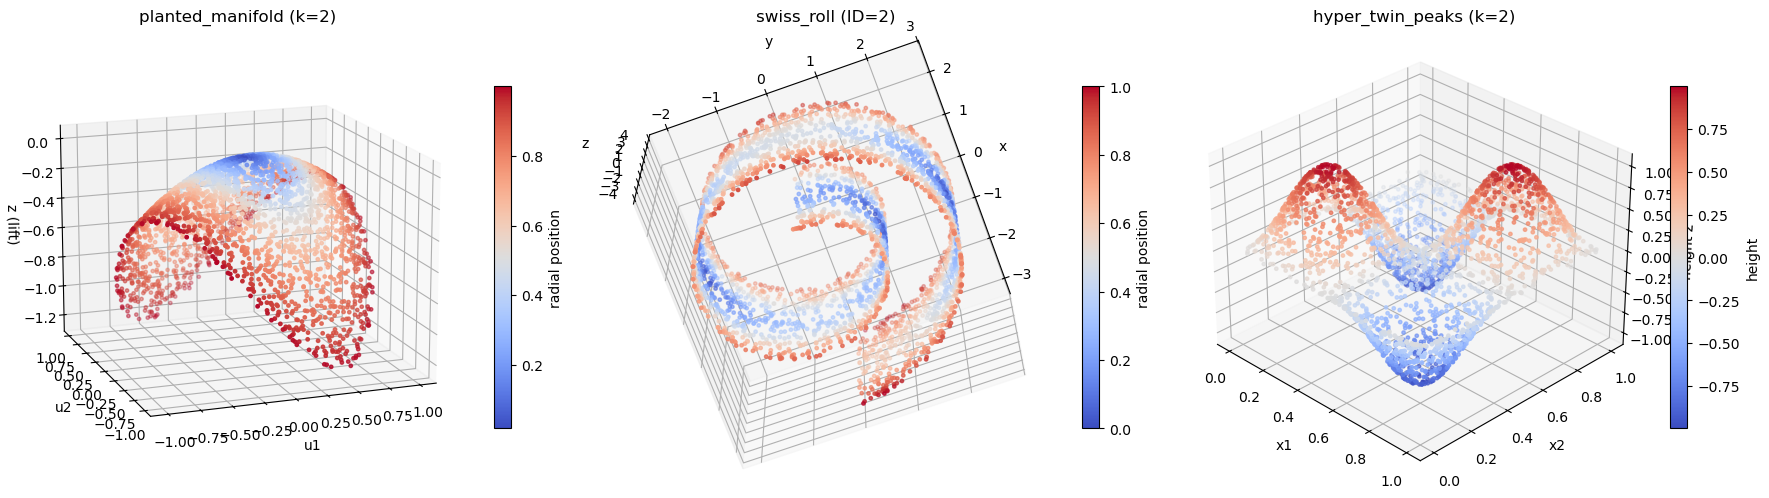

In [64]:
ds_pm = planted_manifold(n, intrinsic_dim=2, D=None, seed=seed)
ds_sr = swiss_roll(n, D=None, seed=seed)
ds_tp = hyper_twin_peaks(n, intrinsic_dim=2, D=None, seed=seed)

fig = plt.figure(figsize=(18, 6))
# planted_manifold (k=2): color = radial position in the ball (u1, u2 columns)
ax1 = fig.add_subplot(131, projection='3d')
radial_pm = np.linalg.norm(ds_pm.X[:, :2], axis=1)
sc1 = ax1.scatter(ds_pm.X[:, 0], ds_pm.X[:, 1], ds_pm.X[:, 2],
                   c=radial_pm, cmap="coolwarm", s=6)
ax1.view_init(elev=15, azim=-110)
ax1.set_xlabel("u1"); ax1.set_ylabel("u2"); ax1.set_zlabel("z (lift)")
ax1.set_title("planted_manifold (k=2)")
fig.colorbar(sc1, ax=ax1, shrink=0.6, label="radial position")

# swiss_roll (ID=2)
ax2 = fig.add_subplot(132, projection='3d')
roll_radial = np.sqrt(ds_sr.X[:, 0]**2 + ds_sr.X[:, 2]**2)
# winding parameter t, not spatial radius
# a min-max normalization of the native radial distance (roll_radial)
# since the roll's centerline radius grows monotonically with the spiral parameter 
# t, this rescaling recovers t itself, so color now tracks 
# "distance traveled along the ribbon from center to outer edge" 
# rather than a fixed spatial axis like height (Z)
t_winding = (roll_radial - roll_radial.min()) / (roll_radial.max() - roll_radial.min())
sc2 = ax2.scatter(ds_sr.X[:, 0], ds_sr.X[:, 1], ds_sr.X[:, 2],
                   c=t_winding, cmap="coolwarm", s=6)
ax2.view_init(elev=-70, azim=20)
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("z")
ax2.set_title("swiss_roll (ID=2)")
fig.colorbar(sc2, ax=ax2, shrink=0.6, label="radial position")

# hyper_twin_peaks (k=2): color = height (3rd native column)
ax3 = fig.add_subplot(133, projection='3d')
sc3 = ax3.scatter(ds_tp.X[:, 0], ds_tp.X[:, 1], ds_tp.X[:, 2],
                   c=ds_tp.X[:, 2], cmap="coolwarm", s=6)
ax3.view_init(azim=-45)
ax3.set_xlabel("x1"); ax3.set_ylabel("x2"); ax3.set_zlabel("height z")
ax3.set_title("hyper_twin_peaks (k=2)")
fig.colorbar(sc3, ax=ax3, shrink=0.6, label="height")

plt.tight_layout()

`M8_Nonlinear, M_N1, M_N2` live in 72–96 ambient dimensions with true ID 12–24, so there is no meaningful 3-axis slice to show. Any arbitrary triple of raw coordinates displays nothing about the manifold's actual shape, since the structure is distributed across far more than 3 dimensions and a random 3-coordinate cut carries no more information than noise would. Unlike the low-ID manifolds, these generators also have no simple closed-form parametric variable (like radial position or height) to color by, since they come from Campadelli et al.'s constructed nonlinear embeddings rather than an explicit low-dimensional formula, so there's no principled coloring choice either. For this section, it's more honest to state plainly that raw or PCA-based visualization isn't informative at this scale, and defer any quantitative check on these three to the ID-estimator calibration step later rather than manufacturing a visual that doesn't actually convey the geometry.

## 1.4 Heterogeneous ID Manifold (Mixed Structure)
*Calibrates Use 4*

| Generator | Ground-truth ID | Ambient dim | Structure | Source |
| --- | --- | --- | --- | --- |
| `swiss_roll_3sphere` | Mixed (2 and 3) | 4 or $D$ | Swiss roll (ID = 2) coexisting with a 3-sphere (ID = 3) | `skdim.datasets.swissRoll3Sph` |

**Why?**

Real galaxy embeddings are heterogeneous populations (galaxies, stars, AGN, QSOs) and lensed sources all share one embedding space. A global estimator like TwoNN returns a single number that may be meaningless across manifolds of different dimension. The pointwise TwoNN distribution should show a bimodal distribution here. If it does not, global TwoNN is masking the heterogeneity and the pointwise check can't be fully trusted on real data.

In [65]:
def swiss_roll_3sphere(
    n_roll: int,
    n_sphere: int,
    D: Optional[int] = None,
    seed: Optional[int] = None,
) -> SyntheticDataset:
    """ Wraps ``skdim.datasets.swissRoll3Sph``; skdim stacks roll rows first,
    then sphere rows, which fixes the label vector
    """
    rng = _rng(seed)
    X4 = skd.swissRoll3Sph(
        n_roll, n_sphere, random_state=int(rng.integers(2**31 - 1))
    )
    labels = np.concatenate(
        [np.zeros(n_roll, dtype=int), np.ones(n_sphere, dtype=int)]
    )
    X = embed_ambient(X4, D, rng)
    return SyntheticDataset(
        "swiss_roll_3sphere", X, {"swiss_roll": 2, "sphere3": 3},
        labels=labels,
        meta=dict(seed=seed, n_roll=n_roll, n_sphere=n_sphere,
                  ambient=D or 4, label_order="roll rows first, then sphere",
                  source="skdim.datasets.swissRoll3Sph"),
    )

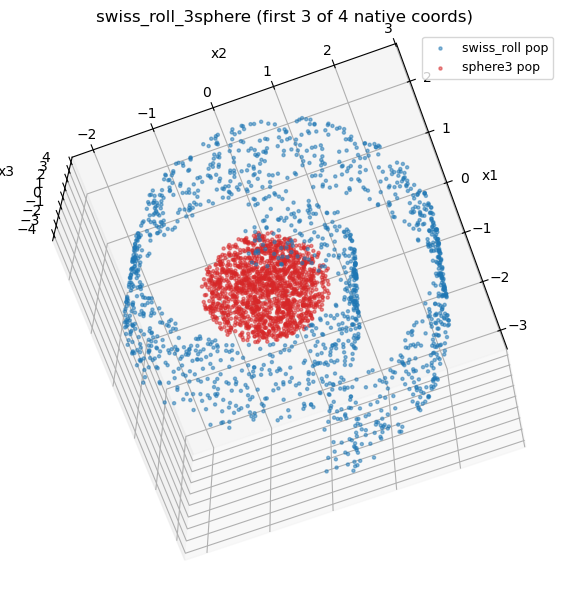

In [81]:
n_roll, n_sphere = 1500, 1500
ds_het = swiss_roll_3sphere(n_roll, n_sphere, D=None, seed=seed)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.scatter(ds_het.X[ds_het.labels==0,0], ds_het.X[ds_het.labels==0,1], ds_het.X[ds_het.labels==0,2],
            c="tab:blue", s=5, alpha=0.5, label="swiss_roll pop")
ax.scatter(ds_het.X[ds_het.labels==1,0], ds_het.X[ds_het.labels==1,1], ds_het.X[ds_het.labels==1,2],
            c="tab:red", s=5, alpha=0.5, label="sphere3 pop")
ax.view_init(elev=-70, azim=20)
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("x3")
ax.set_title("swiss_roll_3sphere (first 3 of 4 native coords)")
ax.legend(fontsize=9)

plt.tight_layout()

## 1.5 Noisy Manifold
*Calibrates Use 5*
| Generator | Ground-truth ID | Structure | Source |
| --- | --- | --- | --- |
| `planted_manifold_noisy` | $k$ (at large scale), $D$ (at noise floor) | Clean manifold + isotropic noise at given SNR | Self-contained; standard noise-floor stress test |
<!-- | `swiss_roll_noisy` | 2 (clean), $D$ (noisy) | Swiss roll + isotropic noise at given SNR | Combines canonical benchmark with noise stress test | -->

**Why?**

Nearest-neighbor ID estimators often inflate toward the ambient dimension when noise dominates the smallest neighbor distances because the local neighborhood then appears $\approx$full-rank rather than tangent to a low-dimensional manifold. *[2]* The noisy variant test how severe this failure is and at what SNR threshold it occurs.
<!-- Comparing `planted_manifold_noisy` against `swiss_roll_noisy` checks whether the failure mode is geometry-dependent or universal. -->

In [66]:
def planted_manifold_noisy(
    n: int,
    intrinsic_dim: int,
    D: int,
    snr: float,
    n_lift: Optional[int] = None,
    lift_scale: float = 0.5,
    seed: Optional[int] = None,
) -> SyntheticDataset:
    """``planted_manifold`` + shared isotropic noise injection at given SNR.

    Ground truth is scale-dependent: ID = k at large scale, -> D at the
    noise floor. Calibrates the SNR threshold at which NN estimators
    inflate toward ambient dimension
    """
    clean = planted_manifold(
        n, intrinsic_dim, D, n_lift=n_lift, lift_scale=lift_scale, seed=seed
    )
    rng = _rng(None if seed is None else seed + 1)  # independent noise stream
    X, sigma = add_isotropic_noise(clean.X, snr, rng)
    meta = dict(clean.meta)
    meta.update(snr=snr, sigma_noise=sigma,
                id_true_note=f"{intrinsic_dim} at large scale, {D} at noise floor")
    return SyntheticDataset("planted_manifold_noisy", X, intrinsic_dim, meta=meta)

Text(0.5, 0.98, 'planted_manifold_noisy (k=2) At Varying SNR')

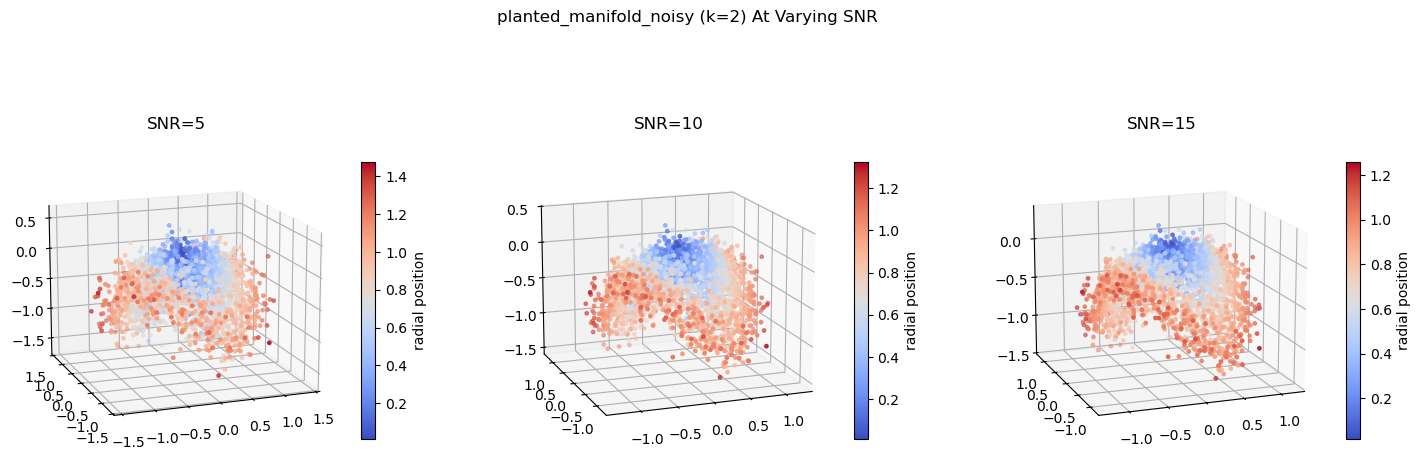

In [86]:
ds_pm_noisy5 = planted_manifold_noisy(n, intrinsic_dim=2, D=None, snr=5.0, seed=seed)
ds_pm_noisy10 = planted_manifold_noisy(n, intrinsic_dim=2, D=None, snr=10.0, seed=seed)
ds_pm_noisy15 = planted_manifold_noisy(n, intrinsic_dim=2, D=None, snr=15.0, seed=seed)

radial_pm5 = np.linalg.norm(ds_pm_noisy5.X[:, :2], axis=1)
radial_pm10 = np.linalg.norm(ds_pm_noisy10.X[:, :2], axis=1)
radial_pm15 = np.linalg.norm(ds_pm_noisy15.X[:, :2], axis=1)

fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(131, projection='3d')
sc1 = ax1.scatter(ds_pm_noisy5.X[:, 0], ds_pm_noisy5.X[:, 1], ds_pm_noisy5.X[:, 2],
                   c=radial_pm5, cmap="coolwarm", s=6)
ax1.view_init(elev=15, azim=-110)
ax1.set_title("SNR=5")
fig.colorbar(sc1, ax=ax1, shrink=0.6, label="radial position")

ax2 = fig.add_subplot(132, projection='3d')
sc2 = ax2.scatter(ds_pm_noisy10.X[:, 0], ds_pm_noisy10.X[:, 1], ds_pm_noisy10.X[:, 2],
                   c=radial_pm10, cmap="coolwarm", s=6)
ax2.view_init(elev=15, azim=-110)
ax2.set_title("SNR=10")
fig.colorbar(sc2, ax=ax2, shrink=0.6, label="radial position")

ax3 = fig.add_subplot(133, projection='3d')
sc3 = ax3.scatter(ds_pm_noisy15.X[:, 0], ds_pm_noisy15.X[:, 1], ds_pm_noisy15.X[:, 2],
                   c=radial_pm15, cmap="coolwarm", s=6)
ax3.view_init(elev=15, azim=-110)
ax3.set_title("SNR=15")
fig.colorbar(sc3, ax=ax3, shrink=0.6, label="radial position")

fig.suptitle("planted_manifold_noisy (k=2) At Varying SNR")

## 1.6 Summary of Data Generators

| Category | Generators | What they test | Calibrates
| --- | --- | --- | --- |
| Nulls | `iso_gaussian`, `aniso_gaussian`, `oblong_normal` | Baseline behavior on structureless data across covariance shapes | Use 1 (gap null), Use 5
| Planted quantity | `planted_quantity` (linear / nonlinear) | Direction vs manifold | Use 3 (probe gap + level-set ID) |
| Low-ID clean manifolds | `planted_manifold` ($k$ =1,2,4,8), `swiss_roll`, `hyper_twin_peaks` | Power: ID recovery at low dimensions across topologies | Use 3
| High-ID clean manifolds | `M8_nonlinear` (ID = 12), `M_N1` (ID = 18), `M_N2` (ID = 24) | Power + bias: ID recovery at representation relevant dimensions | Use 1, Use 5
| Heterogeneous ID | `swiss_roll_3sphere` | Mixed-manifold detection: can global/pointwise TwoNN flag heterogeneity? | Use 4
| Noisy manifolds | `planted_manifold_noisy`, | Noise robustness: at what SNR does TwoNN break? | Use 1, Use 3, Use 5

# 2. ID Estimators

Some previous applications of ID in astronomy:

[7] [Intrinsic Dimension Estimation for Radio Galaxy Zoo using Diffusion Models](https://arxiv.org/html/2511.11490v1)  
Radio Galaxy Zoo work has estimated ID on radio galaxy images, finding that out-of-distribution sources exhibit higher ID and that radio data has much higher ID than natural image datasets, likely due to inherent noise.

[Benchmarking foundation models for unsupervised discovery in ...](https://openreview.net/forum?id=xRD5qFxcdW)  

[Examining Vision Foundation Models for Optical and Radio Astronomy ...](https://arxiv.org/html/2409.11175v4) 

## TwoNN

`from skdim.id import TwoNN`

Explain what it is, include the step by step algorithm, limitations and then test it out on the above datasets


References:

[two-nn-dimensionality-estimator/twonn.py at master · jmmanley/two-nn-dimensionality-estimator](https://github.com/jmmanley/two-nn-dimensionality-estimator/blob/master/twonn.py) 

[[PDF] Stringer et al - 2019 - Science.pdf - Steinmetz Lab](http://www.steinmetzlab.net/assets/img/Stringer%20et%20al%20-%202019%20-%20Science.pdf) 

[Intrinsic Dimension of Data Representations in Deep Neural Networks](https://github.com/ansuini/IntrinsicDimDeep) 

## Other ID Estimators

- **lPCA (Fukunaga-Olsen)**: more robust to noise, separates signal eigenvalues from the noise floor. `from skdim.id import lPCA`
- **DANCo**: accurate but slow; useful as a ground-truth check on a few representative layers. `from skdim.id import DANCo`

# Citations

Set of synthetic manifolds with known intrinsic dimension described by Hein et al. and Campadelli et al. ([Campadelli2015](https://onlinelibrary.wiley.com/doi/10.1155/2015/759567))

[3] [[PDF] High-dimensional geometry of population responses in visual cortex](http://www.steinmetzlab.net/assets/img/Stringer%20et%20al%20-%202019%20-%20Nature.pdf)  
[4] [Intrinsic dimension of data representations in deep neural networks](https://arxiv.org/abs/1905.12784)  
[5] [Intrinsic Dimension in Data Analysis - Emergent Mind](https://www.emergentmind.com/topics/intrinsic-dimension-id)